In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [24]:
df=pd.read_csv('investments_VC.csv',encoding='ISO-8859-1')

In [31]:
df

,name,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,#waywire,|Entertainment|Politics|Social Media|News|,News,1750000.0,acquired,USA,NY,New York City,New York,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,&TV Communications,|Games|,Games,4000000.0,operating,USA,CA,Los Angeles,Los Angeles,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,'Rock' Your Paper,|Publishing|Education|,Publishing,40000.0,operating,EST,NaN,Tallinn,Tallinn,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,(In)Touch Network,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,1500000.0,operating,GBR,NaN,London,London,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-R- Ranch and Mine,|Tourism|Entertainment|Games|,Tourism,60000.0,operating,USA,TX,Dallas,Fort Worth,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
status_counts = df['status'].value_counts(dropna=False)

check = len(df) - status_counts.get('acquired', 0) - status_counts.get('closed', 0) - status_counts.get('operating', 0)

missing_values = df["status"].isna().sum()

other = check - missing_values

print(f"There are {status_counts.get('acquired', 0)} acquired companies")
print(f"There are {status_counts.get('closed', 0)} closed companies")
print(f"There are {status_counts.get('operating', 0)} operating companies")
print(f"There are {missing_values} NaN values")
print(f"There are {other} other values")

There are 3692 acquired companies
There are 2603 closed companies
There are 41829 operating companies
There are 6170 NaN values
There are 0 other values


To reduce unnecessary and redundant data, we delete columns that are not relevant for model development. We want to remove post_ipo_equity and post_ipo_debt as well since this it´s not interesting to us, as we are only looking at Start-ups. We want to exclude debt_financing since this distorts the result, as debt financing is not necessarily a good prediction for success and we focus on venture capital which is generally considered as equity investment.

In [28]:
df=df.drop(["permalink", "homepage_url", "post_ipo_equity", "post_ipo_debt", "debt_financing"], axis=1)

In [30]:
# Ensure column names are trimmed
df.columns = df.columns.str.strip()

# Directly convert 'funding_total_usd' to a float, thereby also transforming "-" to NaN
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'].str.replace(',', ''), errors='coerce')

In [32]:
df['market']

0                News 
1               Games 
2          Publishing 
3         Electronics 
4             Tourism 
             ...      
54289              NaN
54290              NaN
54291              NaN
54292              NaN
54293              NaN
Name: market, Length: 54294, dtype: str

In [33]:
# Turning all of our Date Columns into pd.datetime, to ensure consistency and the right data type 
df['founded_at'] =  pd.to_datetime(df['founded_at'], format='%Y-%m-%d', errors = 'coerce')
df['first_funding_at'] =  pd.to_datetime(df['first_funding_at'], format='%Y-%m-%d', errors = 'coerce')
df['last_funding_at'] =  pd.to_datetime(df['last_funding_at'], format='%Y-%m-%d', errors = 'coerce')
df['founded_year'] =  pd.to_datetime(df['founded_year'], format='%Y', errors = 'coerce')
df['founded_month'] =  pd.to_datetime(df['founded_month'], format='%Y-%m', errors = 'coerce')

In [37]:
x=(df.isna().sum()/len(df))*100 #missing values percentage
y=df.columns  #columns in dataframe
z=df.isna().sum() #missing values in each column
dict={'missing values percentage':x,'columns':y,'missing values in each column':z}
df1=pd.DataFrame(dict)

In [38]:
df1

,missing values percentage,columns,missing values in each column
name,8.945740,name,4857
category_list,16.239363,category_list,8817
market,16.252256,market,8824
funding_total_usd,24.656500,funding_total_usd,13387
status,11.364055,status,6170
country_code,18.655837,country_code,10129
state_code,44.448742,state_code,24133
region,18.655837,region,10129
city,20.208494,city,10972
funding_rounds,8.943898,funding_rounds,4856


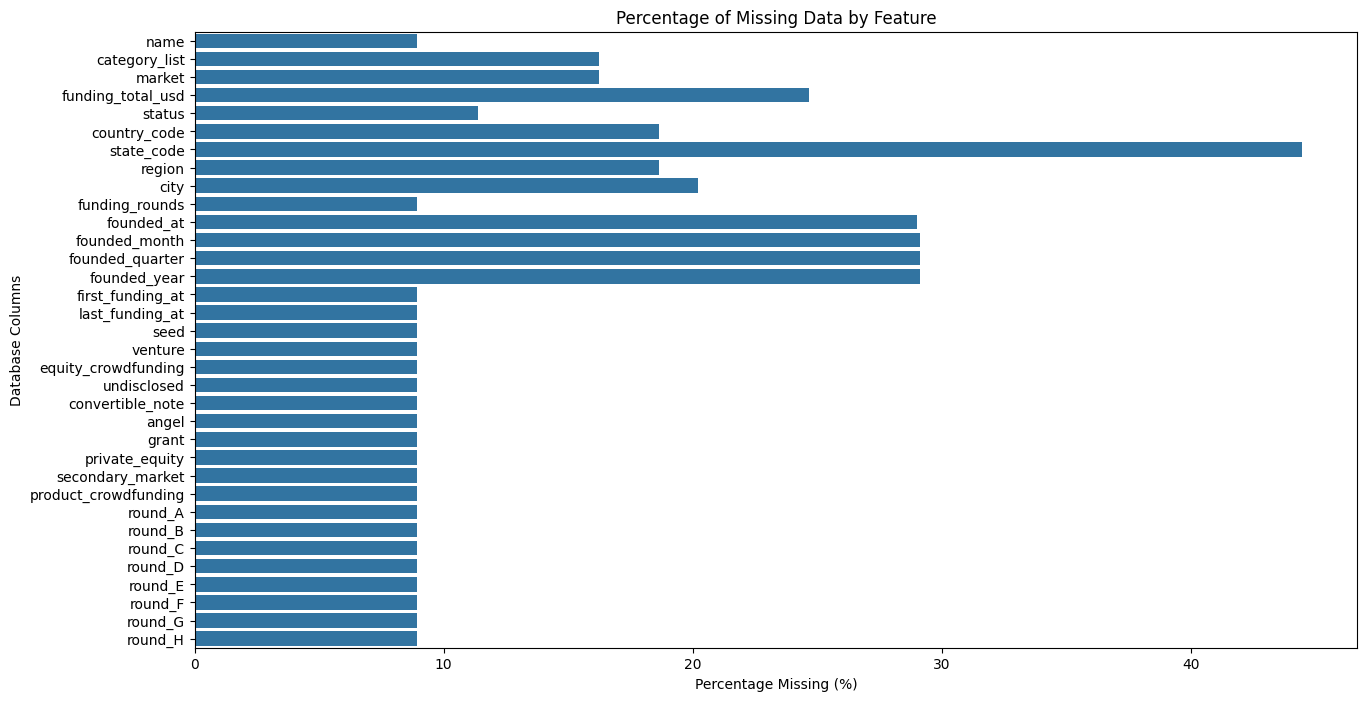

In [39]:
plt.figure(figsize=(15, 8))
sns.barplot(x='missing values percentage', y='columns', data=df1)
plt.title('Percentage of Missing Data by Feature')
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Database Columns')
plt.show()

Key Observations

Highly Missing Data State Code: Has the highest number of missing values at 12,192, suggesting many entries may lack this information, possibly due to non-U.S. entries or incomplete records. Funding Total USD and City: Also have a significant number of missing values (5,694 and 3,132 respectively), impacting analyses dependent on geographical and funding insights.

Moderate Missing Data Country Code and Region: Both have 2,755 missing entries, which could hinder geographic segmentation or market analysis. Market and Category List: Each missing 1,567 and 1,562 values respectively, potentially affecting industry-specific analyses.

Minimal or No Missing Data Columns related to funding rounds (e.g., Round_A, Round_B), and operational metrics (e.g., Seed, Grant) show no missing data, suggesting well-maintained or mandatory fields.

Interpretation and Implications

Geographic Data Gaps Significant missing values in State Code, City, Country Code, and Region imply challenges in performing detailed geographical analysis. This may be due to the dataset including global companies where such information is not uniformly available. However, this will pose no problem to our analysis, since we are building geographical features later in part 3 based on an additional datasets.

Market and Category Gaps Missing data in market and category_list may impede specific industry or market-specific studies, as understanding the segments these companies operate in would be limited. Also this will not be a proble for our analsis, because we later on build a feature based on industry mapping on the given market data and do not use categeory data, because in venture capital only inudstry has a dsigiifcant impact.

Funding Gaps One of the columns with the most missing data is 'Funding Total USD.' This is likely because these startups did not receive funding, which is quite normal, considering that venture capital is a highly selective industry, and only a small percentage of startups secure funding.

As explained above, a key variable for analysis is the "status" column, which is essential for constructing the target variable. Rows with an empty status value are unusable and can be discarded. For other columns, particularly those related to funding rounds (e.g., Pre-Seed, Seed, Series A), we need to fill them with zeros rather than dropping them. This is because an empty value in a funding-related column does not necessarily mean we have to discard the row. As these rounds follow a chronological sequence, a startup might raise a Pre-Seed round and not proceed to raise any more rounds.